In [29]:
!pip install tqdm

     ---------------------------------------- 0.0/57.7 kB ? eta -:--:--
     ------------- ------------------------ 20.5/57.7 kB 640.0 kB/s eta 0:00:01
     -------------------------------------- 57.7/57.7 kB 765.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/78.4 kB ? eta -:--:--
   ---------------------------------------- 78.4/78.4 kB ? eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import matplotlib.pyplot as plt
import numpy as np
from mazelib import Maze
from mazelib.generate.BacktrackingGenerator import BacktrackingGenerator
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

In [2]:
ACTIONS = np.array([
    (-1, 0), # down
    (1, 0),  # up
    (0, -1), # left
    (0, 1),  # right
], dtype=np.int32)

In [3]:
def generate_one(cells_h: int, cells_w: int, seed: int):
    np.random.seed(seed)
    maze = Maze(seed = seed)
    maze.generator = BacktrackingGenerator(cells_h, cells_w)
    maze.generate()

    grid = np.array(maze.grid, dtype=np.int8)
    start = (1, 1)
    goal = (grid.shape[0] - 2, grid.shape[1] - 2)

    grid[start] = 0
    grid[goal] = 0

    return grid, start, goal

In [4]:
def plot_maze(grid: np.ndarray, start: tuple[int, int], goal: tuple[int, int]):
    h, w = grid.shape
    img = np.zeros((h, w, 3), dtype=np.float32)
    img[grid==1] = [0.08, 0.08, 0.08]
    img[grid==0] = [0.97, 0.97, 0.97]
    img[start] = [0.20, 0.75, 0.20]
    img[goal] = [0.85, 0.20, 0.20]

    plt.figure(figsize=(5, 5))
    plt.imshow(img, interpolation="nearest")
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show()

In [5]:
class MazeEnv:
    def __init__(self, grid: np.ndarray, start=(1, 1), goal=None):
        self.grid = grid
        self.h, self.w = grid.shape
        self.start = start
        self.goal = goal if goal is not None else (self.h -2, self.w - 2)

    def reset(self):
        return self.start

    def is_open(self, r, c):
        return 0 <= r < self.h and 0 <= c < self.w and self.grid[r, c] == 0

    def step(self, state, action):
        r, c = state
        dr, dc = ACTIONS[action]
        nr, nc = r + dr, c + dc

        if not self.is_open(nr, nc):
            nr, nc = r, c

        next_state = (int(nr), int(nc))
        done = next_state == self.goal
        reward = 1 if done else 0
        return next_state, reward, done

In [6]:
class MLPPolicyValue(nn.Module):
    def __init__(self, H: int, W: int, in_channels: int=3, hidden: int=512):
        super().__init__()
        self.H = H
        self.W = W
        self.in_channels = in_channels

        obs_dim = in_channels * H * W

        self.fc1 = nn.Linear(obs_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)

        self.pi = nn.Linear(hidden, 4)
        self.v = nn.Linear(hidden, 1)

        nn.init.orthogonal_(self.fc1.weight, gain=1.0)
        nn.init.orthogonal_(self.fc2.weight, gain=1.0)
        nn.init.orthogonal_(self.pi.weight, gain=0.01)
        nn.init.orthogonal_(self.v.weight, gain=1.0)

        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)
        nn.init.zeros_(self.pi.bias)
        nn.init.zeros_(self.v.bias)

    def forward(self, obs: torch.Tensor):
        B = obs.shape[0]
        x = obs.view(B, -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        logits = self.pi(x) # (B, 4)
        value = self.v(x).squeeze(-1) # (B,)
        return logits, value        

In [7]:
def build_obs(grid: torch.Tensor, agent_rc: tuple[int, int], goal_rc: tuple[int, int]):
    """
    grid: (H, W) int/bool/float
    return obs: (3, H, W) float 32
    """
    H, W = grid.shape
    wall = grid.float()

    agent = torch.zeros((H, W), dtype=torch.float32)
    goal = torch.zeros((H, W), dtype=torch.float32)
    ar, ac = agent_rc
    gr, gc = goal_rc
    agent[ar, ac] = 1.0
    goal[gr, gc] = 1.0

    obs = torch.stack([wall, agent, goal], dim=0)
    return obs

In [8]:
class RolloutBuffer:
    def __init__(self):
        self.buffer = list()

    def store(self, transition):
        self.buffer.append(transition)

    def sample(self):
        states, actions, rewards, next_states, dones = map(np.array, zip(*self.buffer))
        self.buffer.clear()
        return (
            torch.FloatTensor(states),
            torch.FloatTensor(actions),
            torch.FloatTensor(rewards).unsqueeze(1),
            torch.FloatTensor(dones).unsqueeze(1)
        )

    @property
    def size(self):
        return len(self.buffer)

In [9]:
class PPO:
    def __init__(self, 
                 policy_value_network:nn.Module,
                 n_steps=2048, 
                 n_epochs=10,
                 batch_size=64,
                 lr=0.0003,
                 gamma=0.99,
                 lmda=0.95,
                 clip_ratio=0.2,
                 vf_coef=1.0,
                 ent_coef=0.01,):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.policy_value_network = policy_value_network
        self.n_steps = 2048
        self.n_epochs = 10,
        self.batch_size = batch_size
        self.lr = lr
        self.gamma = gamma
        self.lmda = lmda
        self.clip_ratio=0.2
        self.vf_coef=1.0
        self.ent_coef=0.01

        self.optimizer = torch.optim.Adam(self.policy_value_network.parameters(), lr=self.lr)

    @torch.no_grad()
    def act(self, state: torch.Tensor, training=True):
        self.policy_value_network.train(training)
        logits, _ = self.policy_value_network(obs.view(1, -1))
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        return action.item()

    def learn(self):
        self.policy_value_network.train()
        states, actions, rewards, next_states, dones = self.buffer.sample()
        states, actions, rewards, next_states, dones = map(lambda x: x.to(self.device), [s, a, r, s_prime, done])

        
        logits, values = self.policy_value_network(states)
        _, next_values = self.policy_value_network(next_states)
        with torch.no_grad():
            delta = rewards + (1 - dones) * self.gamma * next_values - values
            adv = torch.clone(delta)
            ret = torch.clone(r)
            ret[-1] += (1 - dones[-1]) * gamma * next_values[-1] 

            for t in reversed(range(len(r) - 1)):
                adv[t] += (1 - dones[t]) * self.gamma * self.lmda * adv[t + 1]
                ret[t] += (1 - dones[t]) * self.gamma * ret[t + 1]

            dist = torch.distributions.Categorical(logits=logits)
            log_probs_old = dist.log_prob(actions)

        dataset = TensorDataset(states, actions, ret, adv, log_probs_old)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        for e in range(self.n_epochs):
            value_losses = []
            policy_losses = []
            entropy_bonuses = []

            for batch in loader:
                state_, action_, ret_, adv_, log_prob_old_ = batch
                logits_, values = self.policy_value_network(state_)
                value_loss = F.mse_loss(values, ret_)

                dist = torch.distributions.Categorical(logits=logits_)
                log_prob = dist.log_prob(action_)

                ratio = (log_prob - log_prob_old).exp()

                surr1 = adv_ * ratio
                surr2 = adv_ * torch.clamp(ratio, 1.0 - self.clip_ratio, 1.0 + self.clip_ratio)

                policy_loss = -torch.min(surr1, surr2).mean()
                entropy_bonus = -dist.entropy().mean()

                loss = policy_loss + self.vf_coef * value_loss + self.ent_coef * entorpy_bonus
                self.optimizer.zero_grad()

                loss.backward()
                self.optimizer.step()

                value_losses.append(value_loss.item())
                policy_losses.append(policy_loss.item())
                entropy_bonuses.append(-entropy_bonus.item())

        result = {'policy_loss': np.mean(policy_losses), 
                  'value_loss': np.mean(value_losses), 
                  'entropy_bonus': np.mean(entropy_bonus)}
        return result
                
    def step(self, transition):
        result = None
        self.buffer.store(transition)
        if self.buffer.size >= self.n_steps:
            result = self.learn()

        return result

In [23]:
def evaluate(grid, start, goal, agent: PPO, eval_iterations, max_steps=350):
    grid_t = torch.from_numpy(grid).float()
    start_t = torch.tensor(start, dtype=torch.long)
    goal_t = torch.tensor(goal, dtype=torch.long)
    env = MazeEnv(grid, start, goal)
    scores = []
    for i in range(eval_iterations):
        state = build_obs(grid_t, start_t, goal_t)
        position = start
        score = 0
        for t in range(max_steps):
            action = agent.act(state, training=False)
            next_position, reward, done = env.step(position, action)
            score += reward
            next_state_t = torch.tensor(next_position, dtype=torch.long)
            state = build_obs(grid_t, next_position, goal_t)
        scores.append(score)

    return round(np.mean(scores), 4)

In [36]:
max_iterations = 100000
eval_intervals = 1000
eval_iterations = 10

grid, start, goal = generate_one(3, 3, 1)
grid_t = torch.from_numpy(grid).float()
start_t = torch.tensor(start, dtype=torch.long)
goal_t = torch.tensor(goal, dtype=torch.long)
env = MazeEnv(grid, start, goal)

policy_value_network = MLPPolicyValue(grid_t.shape[0], grid_t.shape[1])
agent = PPO(policy_value_network=policy_value_network)

logger = []


position_t = start_t
position = start
state = build_obs(grid_t, start_t, goal_t)

for t in tqdm(range(1, max_iterations + 1)):
    action = agent.act(state)
    next_position, reward, done = env.step(position, action)
    next_position_t = torch.tensor(next_position, dtype=torch.long)

    state = build_obs(grid_t, position_t, goal_t)
    next_state = build_obs(grid_t, next_position_t, goal_t)
    result = agent.step((state, action, reward, next_state, done))

    state = next_state

    if result is not None:
        logger.append([t, 'policy_loss', result['policy_loss']])
        logger.append([t, 'value_loss', result['value_loss']])
        logger.append([t, 'entropy_bonus', result['entropy_bonus']])

    if done:



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:16<00:00, 6213.40it/s]


In [37]:
print(action)

2


In [24]:
evaluate(grid, start, goal, agent, 10)

np.float64(0.0)

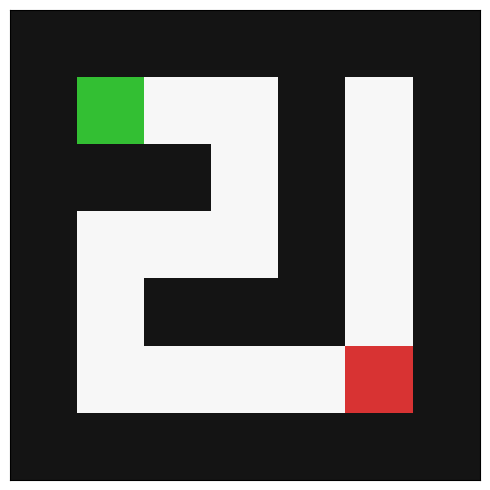

In [13]:
grid, start, goal = generate_one(3, 3, 1)
env = MazeEnv(grid, start, goal)

grid_t = torch.from_numpy(grid).float()
start_t = torch.tensor(start, dtype=torch.long)
goal_t = torch.tensor(goal, dtype=torch.long)
obs = build_obs(grid_t, start_t, goal_t)
policy_value = MLPPolicyValue(grid_t.shape[0], grid_t.shape[1])
logits, value = policy_value(obs.view(1, -1))

dist = torch.distributions.Categorical(logits=logits)
action = dist.sample()
next_state, reward, done = env.step(start, action)

plot_maze(grid, next_state, goal)

In [15]:
agent = PPO(policy_value_network=policy_value)